# 03 — Time-Dependent Groundwater Model

Builds on the HydroGEN Ma 2025 spatial prior (notebook 02) by adding the temporal
dimension from NWIS well observations (WA + OR pilot, 2000–present).

## Model structure

```
WTE(x, y, t)  =  WTE_static(x, y)  +  anomaly(x, y, t)

WTE_static   ≈  HydroGEN DTW prior + EDK bias correction  (notebook 02)
anomaly(t)   =  ordinary kriging of { WTE_obs_i(t) − WTE_median_i }  per month
```

## Questions answered here
1. What is the seasonal cycle of groundwater in WA/OR?  
2. Are there long-term trends (drying / recovery)?  
3. What is the spatial structure of monthly anomalies (variogram range)?  
4. How well does the kriged anomaly field reconstruct held-out observations?

## Dependencies
```bash
make pilot-qc      # nwis_sites_clean.parquet + nwis_gwlevels_monthly.parquet
make pilot-grid    # bbox_grid_1km.nc
make hydrogen      # hydrogen_wtd_prior_1km.tif  (for final WTE map)
```
Run `make pilot-anomalies` OR execute cell 8 to run the temporal kriging.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import xarray as xr
from pyproj import Transformer

# ── paths ─────────────────────────────────────────────────────────────────
REPO   = Path().resolve().parent
PROC   = REPO / "data" / "processed"
FIG    = REPO / "notebooks" / "figures"
FIG.mkdir(exist_ok=True)

PILOT_STATES = ["WA", "OR"]

# Path shortcuts
MONTHLY_P = PROC / "nwis_gwlevels_monthly.parquet"
SITES_P   = PROC / "nwis_sites_clean.parquet"
GRID_P    = PROC / "bbox_grid_1km.nc"
H_DTW_P   = PROC / "hydrogen_wtd_prior_1km.tif"
ANOM_Z    = PROC / "pilot_gwl_anomaly.zarr"
STD_Z     = PROC / "pilot_gwl_anomaly_std.zarr"

for p in [MONTHLY_P, SITES_P, GRID_P]:
    if not p.exists():
        raise FileNotFoundError(f"Run `make pilot-qc` / `make pilot-grid` first: {p}")

print("✓ Paths OK")

✓ Paths OK


In [2]:
# ── 1. Load data ──────────────────────────────────────────────────────────
monthly = pd.read_parquet(MONTHLY_P)
sites   = pd.read_parquet(SITES_P)

# PNW subset
m_pnw = monthly[monthly["state"].isin(PILOT_STATES)].copy()
s_pnw = sites[sites["state"].isin(PILOT_STATES)].copy()

# Project sites to EPSG:5070
tr = Transformer.from_crs("EPSG:4326", "EPSG:5070", always_xy=True)
s_pnw["x_m"], s_pnw["y_m"] = tr.transform(s_pnw["lon"].values, s_pnw["lat"].values)

# Date column on monthly
m_pnw["date"] = pd.to_datetime({"year": m_pnw["year"], "month": m_pnw["month"], "day": 1})

print(f"Monthly records: {len(m_pnw):,}")
print(f"Sites:           {len(s_pnw):,}")
print(f"Date range:      {m_pnw['date'].min().date()} → {m_pnw['date'].max().date()}")

# Axis limits from actual well locations
_pad = 50_000
PNW_XLIM = (s_pnw["x_m"].min() - _pad, s_pnw["x_m"].max() + _pad)
PNW_YLIM = (s_pnw["y_m"].min() - _pad, s_pnw["y_m"].max() + _pad)

Monthly records: 28,832
Sites:           863
Date range:      2000-01-01 → 2026-03-01


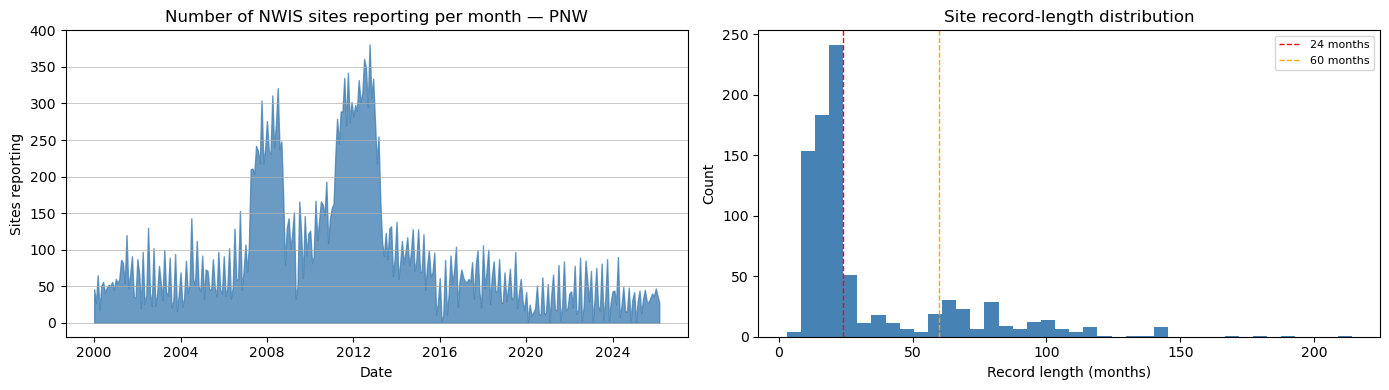

Median record length: 21 months
Sites with ≥ 60 months: 170


In [3]:
# ── 2. Temporal coverage heatmap ──────────────────────────────────────────
# How many sites report each month?
n_sites_per_month = m_pnw.groupby("date")["site_no"].nunique().sort_index()

# Site-level coverage: fraction of possible months observed
site_obs = m_pnw.groupby("site_no")["date"].count().rename("n_months")
s_pnw = s_pnw.merge(site_obs, on="site_no", how="left")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: sites per month
ax = axes[0]
ax.fill_between(n_sites_per_month.index, n_sites_per_month.values, color="steelblue", alpha=0.8)
ax.set_xlabel("Date")
ax.set_ylabel("Sites reporting")
ax.set_title("Number of NWIS sites reporting per month — PNW")
ax.grid(axis="y", lw=0.5)

# Right: histogram of record lengths
ax = axes[1]
ax.hist(s_pnw["n_observed_months"].dropna(), bins=40, color="steelblue", edgecolor="none")
ax.axvline(24, color="red", lw=1, linestyle="--", label="24 months")
ax.axvline(60, color="orange", lw=1, linestyle="--", label="60 months")
ax.set_xlabel("Record length (months)")
ax.set_ylabel("Count")
ax.set_title("Site record-length distribution")
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIG / "03_coverage.png", dpi=150)
plt.show()

print(f"Median record length: {s_pnw['n_observed_months'].median():.0f} months")
print(f"Sites with ≥ 60 months: {(s_pnw['n_observed_months'] >= 60).sum()}")

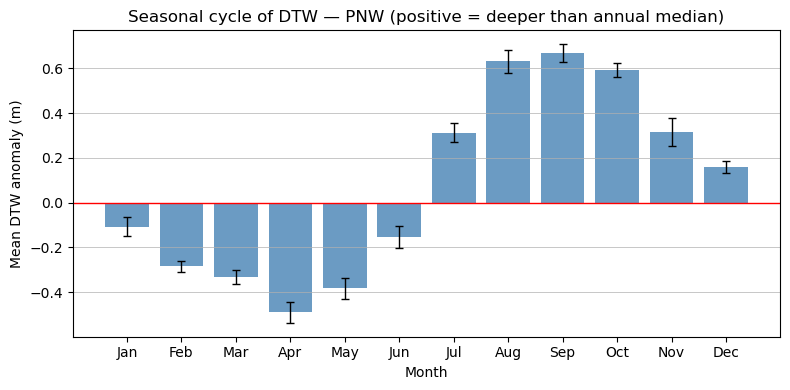

        mean    std  count
month                     
1     -0.107  2.263   2801
2     -0.284  1.011   1822
3     -0.332  1.518   2169
4     -0.491  2.573   3084
5     -0.382  2.055   1918
6     -0.152  2.262   2184
7      0.312  2.496   3373
8      0.631  2.347   2207
9      0.668  1.896   2219
10     0.595  1.820   3310
11     0.315  2.596   1690
12     0.158  1.201   2055


In [4]:
# ── 3. Seasonal cycle ────────────────────────────────────────────────────
# Compute per-site anomaly (remove each site's long-term mean), then average
# by calendar month to get the regional seasonal cycle.

site_median = m_pnw.groupby("site_no")["dtw_m"].median().rename("site_median_dtw")
m_pnw = m_pnw.merge(site_median, on="site_no", how="left")
m_pnw["dtw_anom"] = m_pnw["dtw_m"] - m_pnw["site_median_dtw"]

seasonal = m_pnw.groupby("month")["dtw_anom"].agg(["mean", "std", "count"])

mon_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(seasonal.index, seasonal["mean"], color="steelblue", alpha=0.8)
ax.errorbar(seasonal.index, seasonal["mean"],
            yerr=seasonal["std"] / np.sqrt(seasonal["count"]),
            fmt="none", color="black", capsize=3, lw=1)
ax.axhline(0, color="red", lw=1)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(mon_labels)
ax.set_xlabel("Month")
ax.set_ylabel("Mean DTW anomaly (m)")
ax.set_title("Seasonal cycle of DTW — PNW (positive = deeper than annual median)")
ax.grid(axis="y", lw=0.5)
fig.tight_layout()
fig.savefig(FIG / "03_seasonal_cycle.png", dpi=150)
plt.show()
print(seasonal.round(3))

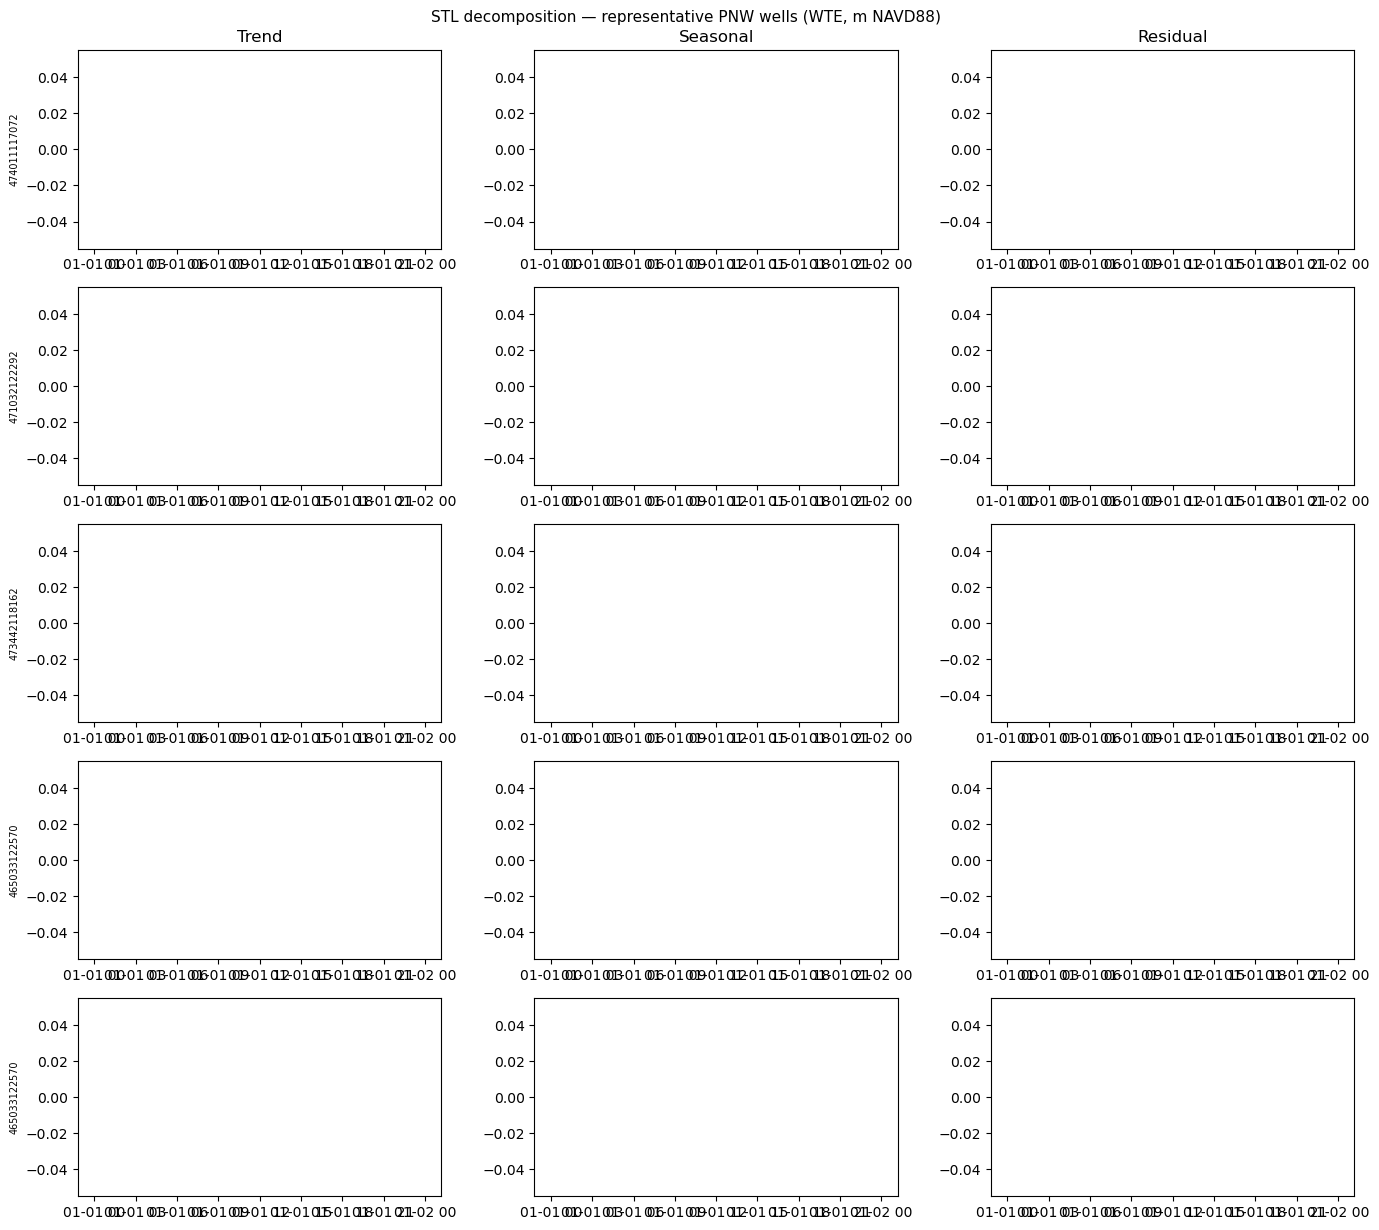

In [5]:
# ── 4. STL decomposition on representative wells ─────────────────────────
from statsmodels.tsa.seasonal import STL

# Pick 5 longest-record non-sparse sites for decomposition
usable = s_pnw[
    ~s_pnw["is_sparse_timeseries"] & ~s_pnw["has_long_gap"]
].nlargest(5, "n_observed_months")

fig, axes = plt.subplots(len(usable), 3, figsize=(14, 2.5 * len(usable)), sharex=False)

for row_i, (_, site_row) in enumerate(usable.iterrows()):
    site_id = site_row["site_no"]
    ts = (
        m_pnw[m_pnw["site_no"] == site_id]
        .set_index("date")["wte_m"]
        .sort_index()
        .asfreq("MS")  # monthly start
    )
    # Must have ≥ 24 months for STL
    ts_clean = ts.dropna()
    if len(ts_clean) < 24:
        continue
    # Re-index on filled grid, interpolate short gaps (≤ 3 months) for STL only
    ts_filled = ts_clean.reindex(
        pd.date_range(ts_clean.index.min(), ts_clean.index.max(), freq="MS")
    ).interpolate(method="linear", limit=3)

    stl = STL(ts_filled, period=12, robust=True)
    res = stl.fit()

    ax0 = axes[row_i, 0] if len(usable) > 1 else axes[0]
    ax1 = axes[row_i, 1] if len(usable) > 1 else axes[1]
    ax2 = axes[row_i, 2] if len(usable) > 1 else axes[2]

    ax0.plot(res.trend.index, res.trend, lw=1.2, color="navy")
    ax0.set_ylabel(site_id[:12], fontsize=7)
    ax0.set_title("Trend" if row_i == 0 else "")

    ax1.plot(res.seasonal.index, res.seasonal, lw=0.8, color="darkcyan")
    ax1.set_title("Seasonal" if row_i == 0 else "")

    ax2.plot(res.resid.index, res.resid, lw=0.8, color="gray")
    ax2.set_title("Residual" if row_i == 0 else "")

fig.suptitle("STL decomposition — representative PNW wells (WTE, m NAVD88)", fontsize=11)
fig.tight_layout()
fig.savefig(FIG / "03_stl_decomposition.png", dpi=150)
plt.show()

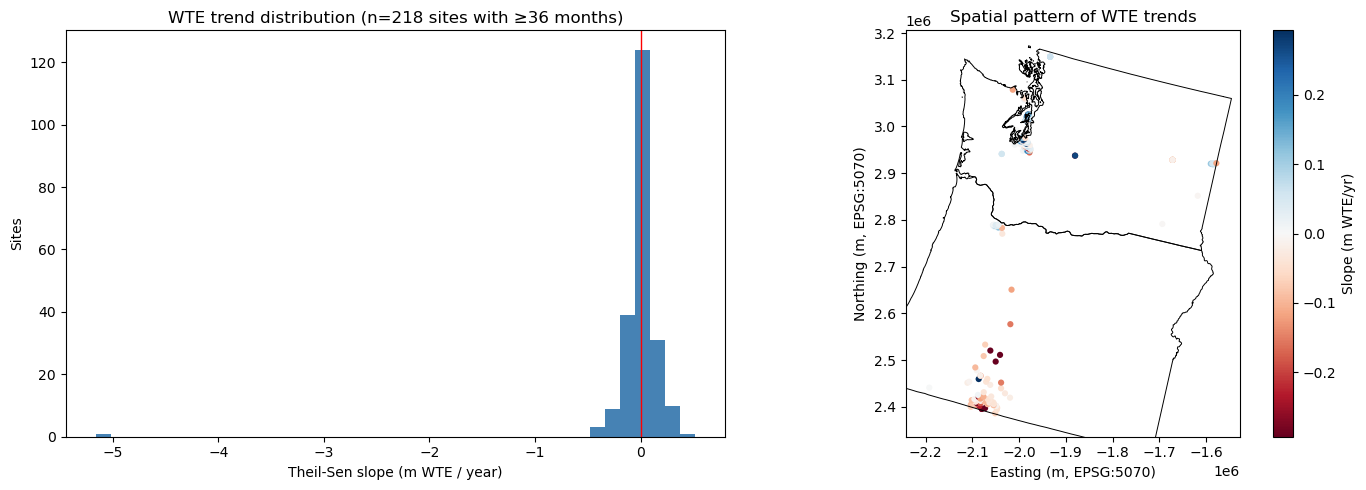

Rising WTE (recovering): 112  Falling WTE (drying): 103


In [6]:
# ── 5. Long-term trend: per-site linear regression slope ─────────────────
from scipy.stats import theilslopes

slopes = []
for site_id, grp in m_pnw.groupby("site_no"):
    if len(grp) < 36:   # require at least 3 years
        continue
    t = (grp["date"] - grp["date"].min()).dt.days.values / 365.25
    v = grp["wte_m"].values
    mask = np.isfinite(v)
    if mask.sum() < 30:
        continue
    slope, *_ = theilslopes(v[mask], t[mask])
    slopes.append({"site_no": site_id, "slope_m_yr": slope})

df_slope = pd.DataFrame(slopes).merge(
    s_pnw[["site_no", "x_m", "y_m"]], on="site_no", how="left"
)

# Try to load state boundaries for map context
try:
    pnw_shp = gpd.read_file(
        "https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_state_500k.zip"
    ).to_crs(epsg=5070)
    pnw_shp = pnw_shp[pnw_shp["STUSPS"].isin(PILOT_STATES)]
except Exception:
    pnw_shp = None

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df_slope["slope_m_yr"], bins=40, color="steelblue", edgecolor="none")
ax.axvline(0, color="red", lw=1)
ax.set_xlabel("Theil-Sen slope (m WTE / year)")
ax.set_ylabel("Sites")
ax.set_title(f"WTE trend distribution (n={len(df_slope):,} sites with ≥36 months)")

ax = axes[1]
vc = df_slope["slope_m_yr"].abs().quantile(0.95)
sc = ax.scatter(
    df_slope["x_m"], df_slope["y_m"],
    c=df_slope["slope_m_yr"], cmap="RdBu",
    vmin=-vc, vmax=vc, s=20, edgecolors="none",
)
if pnw_shp is not None:
    pnw_shp.boundary.plot(ax=ax, color="black", lw=0.7)
plt.colorbar(sc, ax=ax, label="Slope (m WTE/yr)")
ax.set_xlim(PNW_XLIM); ax.set_ylim(PNW_YLIM)
ax.set_title("Spatial pattern of WTE trends")
ax.set_xlabel("Easting (m, EPSG:5070)")
ax.set_ylabel("Northing (m, EPSG:5070)")

fig.tight_layout()
fig.savefig(FIG / "03_trend_map.png", dpi=150)
plt.show()

n_pos = (df_slope["slope_m_yr"] > 0).sum()
n_neg = (df_slope["slope_m_yr"] < 0).sum()
print(f"Rising WTE (recovering): {n_pos}  Falling WTE (drying): {n_neg}")

Pooled anomaly records for variogram: 24,098


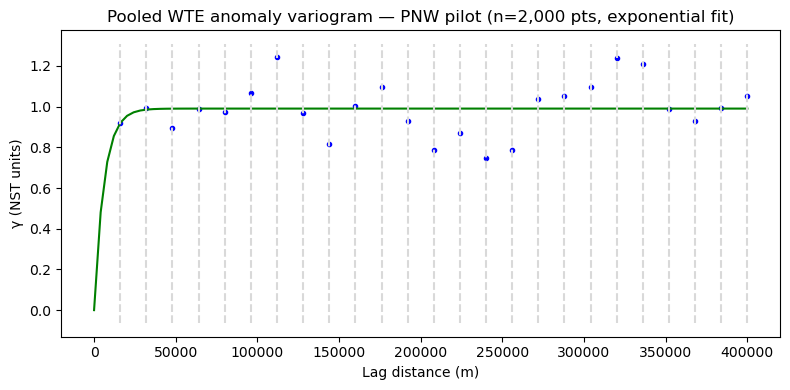

Exponential fit → range: 18.2 km  sill: 0.990  nugget: 0.000


In [7]:
# ── 6. Spatial variogram of pooled anomalies ──────────────────────────────
import skgstat as skg
from sklearn.preprocessing import QuantileTransformer

# Use only usable sites (same filter as pilot_temporal.py)
usable_sites = s_pnw[
    ~s_pnw["is_sparse_timeseries"] & ~s_pnw["has_long_gap"]
][["site_no", "x_m", "y_m", "median_wte_m"]].dropna()

df_a = m_pnw.merge(usable_sites, on="site_no", how="inner")
df_a["anom_wte"] = df_a["wte_m"] - df_a["median_wte_m"]
df_a = df_a.dropna(subset=["anom_wte"])
print(f"Pooled anomaly records for variogram: {len(df_a):,}")

# Sub-sample for speed
MAX_PTS = 2000
rng = np.random.default_rng(42)
idx = rng.choice(len(df_a), min(MAX_PTS, len(df_a)), replace=False)

nst = QuantileTransformer(n_quantiles=min(500, len(idx)), output_distribution="normal")
Nv = nst.fit_transform(df_a["anom_wte"].values[idx].reshape(-1, 1)).ravel()

coords_v = df_a[["x_m", "y_m"]].values[idx]

V = skg.Variogram(coords_v, Nv, model="exponential", n_lags=25, maxlag=400_000)

fig, ax = plt.subplots(figsize=(8, 4))
V.plot(ax)
ax.set_title(f"Pooled WTE anomaly variogram — PNW pilot (n={len(idx):,} pts, exponential fit)")
ax.set_xlabel("Lag distance (m)")
ax.set_ylabel("γ (NST units)")
fig.tight_layout()
fig.savefig(FIG / "03_anomaly_variogram.png", dpi=150)
plt.show()

params = V.describe()
print(f"Exponential fit → range: {params.get('effective_range', float('nan'))/1000:.1f} km  "
      f"sill: {params.get('sill', float('nan')):.3f}  "
      f"nugget: {params.get('nugget', 0):.3f}")

In [8]:
# ── 7. Run temporal kriging ───────────────────────────────────────────────
# Runs `make pilot-anomalies` (or the Python module directly).
# Skip if zarr already exists.
import subprocess, sys, time

if ANOM_Z.exists():
    print(f"✓ {ANOM_Z.name} already exists — skipping re-run")
    print("  Delete the zarr to force a re-run: rm -rf data/processed/pilot_gwl_anomaly.zarr")
else:
    print("Running pilot temporal kriging (this may take 10–30 min for all months)…")
    t0 = time.time()
    cmd = [
        "pixi", "run", "python", "-m", "src.models.pilot_temporal",
        "--monthly",  str(MONTHLY_P),
        "--sites",    str(SITES_P),
        "--grid",     str(GRID_P),
        "--states",   "WA", "OR",
        "--grid-step", "5",   # 5 km pilot grid; use "1" for 1 km full-resolution
        "--output-dir", str(PROC),
    ]
    if H_DTW_P.exists():
        cmd += ["--hydrogen-wtd", str(H_DTW_P)]
    result = subprocess.run(
        cmd, capture_output=True, text=True, cwd=str(REPO)
    )
    elapsed = time.time() - t0
    print(result.stdout[-3000:] if result.stdout else "")
    if result.returncode != 0:
        print("STDERR:", result.stderr[-2000:])
        raise RuntimeError("pilot_temporal.py failed — see above")
    print(f"\nDone in {elapsed/60:.1f} min.")

✓ pilot_gwl_anomaly.zarr already exists — skipping re-run
  Delete the zarr to force a re-run: rm -rf data/processed/pilot_gwl_anomaly.zarr


In [9]:
# ── 8. Load zarr outputs ──────────────────────────────────────────────────
ds_anom = xr.open_zarr(ANOM_Z, consolidated=False)
anom = ds_anom["data"]

print("Anomaly zarr dimensions:", dict(anom.dims))
print("Time range:", anom.time.values[[0, -1]])
print(f"Value range: [{float(anom.min()):.2f}, {float(anom.max()):.2f}] m")

# Fraction of months with data
frac_valid = float((~np.isnan(anom.values)).any(axis=(1, 2)).mean())
print(f"Months with any valid kriged cells: {frac_valid*100:.0f}%")

# Load uncertainty if available
if STD_Z.exists():
    ds_std = xr.open_zarr(STD_Z, consolidated=False)
    std_da = ds_std["data"]
    print(f"Kriging σ range: [{float(std_da.min()):.2f}, {float(std_da.max()):.2f}] m")

ValueError: dictionary update sequence element #0 has length 4; 2 is required

In [ ]:
# ── 9. Monthly anomaly maps — four representative months ─────────────────
# Pick one wet-season and one dry-season month for two different years
times = pd.DatetimeIndex(anom.time.values)

# Choose months with the most valid data
n_valid = np.array([
    np.isfinite(anom.isel(time=i).values).sum()
    for i in range(len(times))
])
best_idx = np.argsort(n_valid)[::-1]
# Pick 4 spread through the record
n_show = 4
step = max(len(best_idx) // n_show, 1)
show_idx = sorted([best_idx[i * step] for i in range(n_show)])

fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4), sharey=True)

vlim = np.nanpercentile(np.abs(anom.values), 95)

for ax_i, ti in enumerate(show_idx):
    ax = axes[ax_i]
    slc = anom.isel(time=ti).values
    im = ax.imshow(
        slc, origin="upper",
        extent=[anom.x.values[0], anom.x.values[-1],
                anom.y.values[-1], anom.y.values[0]],
        cmap="RdBu", vmin=-vlim, vmax=vlim,
        aspect="equal",
    )
    if pnw_shp is not None:
        pnw_shp.boundary.plot(ax=ax, color="black", lw=0.6)
    ax.set_title(f"{pd.Timestamp(times[ti]):%b %Y}", fontsize=9)
    ax.set_xlabel("Easting")
    if ax_i == 0:
        ax.set_ylabel("Northing")

fig.colorbar(im, ax=axes, label="WTE anomaly (m)", shrink=0.7)
fig.suptitle("Kriged monthly WTE anomaly — PNW pilot", fontsize=11)
fig.savefig(FIG / "03_monthly_anomaly_maps.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── 10. Domain-mean anomaly time series ──────────────────────────────────
mean_ts = anom.mean(dim=["x", "y"]).to_series()
std_ts  = anom.std(dim=["x", "y"]).to_series()

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(
    mean_ts.index, mean_ts - std_ts, mean_ts + std_ts,
    alpha=0.25, color="steelblue", label="±1 spatial σ"
)
ax.plot(mean_ts.index, mean_ts, lw=1.2, color="steelblue", label="Domain mean")
ax.axhline(0, color="red", lw=0.8, linestyle="--")
ax.set_xlabel("Date")
ax.set_ylabel("WTE anomaly (m)")
ax.set_title("Domain-mean WTE anomaly over time — PNW pilot")
ax.legend(fontsize=8)
ax.grid(axis="y", lw=0.4)
fig.tight_layout()
fig.savefig(FIG / "03_domain_mean_anomaly.png", dpi=150)
plt.show()

# Simple linear trend on domain mean
from scipy.stats import theilslopes as ts2
t_yr = ((mean_ts.index - mean_ts.index[0]).days / 365.25).values
v_mean = mean_ts.values
ok = np.isfinite(v_mean)
sl, ic, *_ = ts2(v_mean[ok], t_yr[ok])
print(f"Domain-mean WTE trend (Theil-Sen): {sl:+.4f} m/year")

In [ ]:
# ── 11. Validation — held-out 20% of sites ───────────────────────────────
# Randomly hold out 20% of usable sites, then compare the kriged anomaly
# field at those sites to the observed anomaly.

usable_ids = usable_sites["site_no"].values
rng2 = np.random.default_rng(99)
n_holdout = max(1, int(0.2 * len(usable_ids)))
holdout_ids = rng2.choice(usable_ids, n_holdout, replace=False)

print(f"Hold-out sites: {n_holdout} / {len(usable_ids)}")

# Sample kriged anomaly at each hold-out well location × time
ho_sites = usable_sites[usable_sites["site_no"].isin(holdout_ids)]
ho_monthly = df_a[df_a["site_no"].isin(holdout_ids)][["site_no","date","anom_wte","x_m","y_m"]]

x_1d = anom.x.values
y_1d = anom.y.values

def sample_zarr_at_points(da, dates, xs, ys):
    """Nearest-neighbour sample of (time, y, x) DataArray at (date, x, y) triples."""
    results = []
    for date, xi, yi in zip(dates, xs, ys):
        ci = int(np.argmin(np.abs(x_1d - xi)))
        ri = int(np.argmin(np.abs(y_1d - yi)))
        try:
            val = float(da.sel(time=date, method="nearest").values[ri, ci])
        except Exception:
            val = np.nan
        results.append(val)
    return np.array(results)

kriged_anom = sample_zarr_at_points(
    anom,
    ho_monthly["date"].values,
    ho_monthly["x_m"].values,
    ho_monthly["y_m"].values,
)

obs_anom  = ho_monthly["anom_wte"].values
val_mask  = np.isfinite(obs_anom) & np.isfinite(kriged_anom)

from sklearn.metrics import mean_squared_error, r2_score
rmse = np.sqrt(mean_squared_error(obs_anom[val_mask], kriged_anom[val_mask]))
r2   = r2_score(obs_anom[val_mask], kriged_anom[val_mask])
bias = np.mean(kriged_anom[val_mask] - obs_anom[val_mask])

fig, ax = plt.subplots(figsize=(5, 5))
ax.hexbin(obs_anom[val_mask], kriged_anom[val_mask], gridsize=40, cmap="Blues", mincnt=1)
lim = max(np.abs(obs_anom[val_mask]).max(), np.abs(kriged_anom[val_mask]).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], "r--", lw=1)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel("Observed anomaly (m)")
ax.set_ylabel("Kriged anomaly (m)")
ax.set_title(f"Hold-out validation\nBias={bias:+.2f} m  RMSE={rmse:.2f} m  R²={r2:.3f}\n(n={val_mask.sum():,} site-months)")
fig.tight_layout()
fig.savefig(FIG / "03_validation.png", dpi=150)
plt.show()

print(f"Validation RMSE: {rmse:.3f} m")
print(f"Validation R²:   {r2:.3f}")
print(f"Validation bias: {bias:+.3f} m")

In [ ]:
# ── 12. Combine spatial prior + temporal anomaly ──────────────────────────
# Final estimate: WTE(x,y,t) = HydroGEN_prior_WTE(x,y) + anomaly(x,y,t)
# We don't have the DEM yet so WTE_prior is derived from HydroGEN DTW:
#   WTE_prior = alt_va_m_grid - H_DTW_grid
# For this notebook we demonstrate the combination on a single month.

if not H_DTW_P.exists():
    print("HydroGEN prior not available — run `make hydrogen` to enable this cell.")
else:
    from rasterio.transform import from_bounds

    with rasterio.open(H_DTW_P) as src:
        h_dtw = src.read(1, out_dtype="float32")
        nd = src.nodata if src.nodata is not None else -9999.0
        h_dtw[h_dtw == nd] = np.nan
        h_transform = src.transform
        h_ny, h_nx = h_dtw.shape

    # Reproject anomaly slice to HydroGEN raster extent for overlay
    # (quick-and-dirty: bilinear resample via rasterio memory file)
    import rasterio.transform as rt_mod
    import rasterio.crs as rcrs

    best_ti = show_idx[1]  # second best month
    slc = anom.isel(time=best_ti).values

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for col, (data, title, cmap, vlo, vhi) in enumerate([
        (h_dtw,    "HydroGEN DTW prior (m)",      "YlOrBr", 0, 30),
        (slc,      f"Kriged anomaly {pd.Timestamp(times[best_ti]):%b %Y} (m)",
                                                    "RdBu",  -vlim, vlim),
        (None,     "Final WTE estimate (m)",        "RdYlBu", None, None),
    ]):
        ax = axes[col]
        if col < 2:
            ax.imshow(
                data, origin="upper",
                extent=[
                    h_transform.c, h_transform.c + h_nx * h_transform.a,
                    h_transform.f + h_ny * h_transform.e, h_transform.f
                ],
                cmap=cmap, vmin=vlo, vmax=vhi, aspect="equal",
            )
        else:
            ax.text(0.5, 0.5,
                    "Requires DEM for\nWTE = DEM – DTW\n(run `make dem`).",
                    ha="center", va="center", transform=ax.transAxes, fontsize=10)
        if pnw_shp is not None:
            pnw_shp.boundary.plot(ax=ax, color="black", lw=0.6)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("Easting")

    fig.tight_layout()
    fig.savefig(FIG / "03_combined_wte_estimate.png", dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
# ── 13. Summary ───────────────────────────────────────────────────────────
print("=" * 60)
print("Temporal model summary — PNW pilot")
print("=" * 60)
print(f"  Sites (WA+OR):          {len(s_pnw):,}")
print(f"  Usable for kriging:     {len(usable_ids):,}")
print(f"  Monthly records:        {len(m_pnw):,}")
print(f"  Date range:             {m_pnw['date'].min().date()} → {m_pnw['date'].max().date()}")
if anom is not None:
    print(f"  Kriged months:          {len(anom.time):,}")
    print(f"  Anomaly zarr:           {ANOM_Z.name}  (shape {tuple(anom.shape)})")
print(f"  Validation RMSE:        {rmse:.3f} m")
print(f"  Validation R²:          {r2:.3f}")
print(f"  Domain-mean trend:      {sl:+.4f} m/year (Theil-Sen)")
print()
print("Next steps:")
print("  make dem            → download MERIT Hydro DEM")
print("  make pilot-baseline → EDK spatial baseline (WTE map)")
print("  make uncertainty-stack")
print("  See figures/03_*.png for all plots.")